# Run Analysis

Loads TensorBoard scalar data from `runs/{folder_name}/{exp_group}/{i}/` and plots
metrics aggregated across the numbered runs (mean line + 95% confidence band).

## 1. Imports

In [1]:
import glob
import os
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

## 2. Global variables

Folder path, display-name mapping, and a fixed color per experiment group.

In [2]:
# This notebook lives in data_analysis/, but runs/ and plots/ live at the repo
# root. Anchor all paths to the project root by walking up from the working
# directory until we find the folder that contains runs/ (works whether the
# kernel's cwd is data_analysis/ or the repo root).
def _find_project_root(marker="runs"):
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, marker)):
            return d
        parent = os.path.dirname(d)
        if parent == d:  # reached filesystem root, give up
            return os.path.abspath(os.getcwd())
        d = parent


PROJECT_ROOT = _find_project_root()

# Root folder that contains the experiment-group sub-folders.
RUNS_ROOT = os.path.join(PROJECT_ROOT, "runs")
FOLDER_NAME = "long_dir" #"basic_comp" #"sac_forge_pih_v1"

# Confidence band: mean +/- Z * standard_error.  1.96 -> ~95% CI.
CI_Z = 1.96

# Keep only the top-N runs per experiment group, ranked by each run's peak
# SUCCESS_METRIC value, before any plotting or tables. -1 keeps all runs.
TOP_N = -1
# Tag used to rank runs for TOP_N (each run's peak value is the ranking key).
SUCCESS_METRIC = "Episode / Success rate"

# Shared x-axis for every plot (all plots use the same x-scale and label).
# XLIM is (min, max) or None to autoscale; None per-bound is allowed.
XLABEL = "Env Steps"
XLIM = (0, 8850)


def _step_ceiling():
    """Largest step used for run selection / table stats: the XLIM upper bound.

    Returns inf if XLIM (or its upper bound) is unset. Both the TOP_N run
    ranking and the best-point table clip to this, so longer runs are truncated
    and every method is compared at equal data efficiency.
    """
    if XLIM is not None and XLIM[1] is not None:
        return XLIM[1]
    return np.inf

# Plots are saved together in one dated folder (computed once here so every
# plot from this run lands in the same folder). The folder is named only by
# date -- no time -- so re-running on the same day overwrites the files:
# runs/{FOLDER_NAME}/plots_{date}/{metric}.svg
PLOTS_DIR = os.path.join(RUNS_ROOT, FOLDER_NAME,
                         f"plots_{datetime.now().strftime('%Y%m%d')}")

# Map raw experiment-group folder names -> pretty names shown in the legend.
DISPLAY_NAMES = {
    "1_fixed": "Fixed",
    "2_VICES": "VICES",
    "3_VICES_OD": "VICES-OD",
    "4_rotated_raw": "GAS",
    "4-1_rotated_fixed": "Known-Rotation",
    "5_MATCH":"MATCH",
    "6_GAS_6D":"GAS-6D",
    "7_VICES_OD_6D": "Vices-OD-6D"
}

# Fixed color per experiment group (keeps colors stable across every plot).
GROUP_COLORS = {
    "1_fixed": "#ff9500",
    "2_VICES": "#ff0000",
    "3_VICES_OD": "#1f77b4",
    "4_rotated_raw": "#1fb426",
    "4-1_rotated_fixed": "#7107b8",
    "5_MATCH": "#e3fc07",
    "6_GAS_6D": "#165E19",
    "7_VICES_OD_6D": "#640f0f",

    #"0_Hybrid_SSL": "#1f77b4",
    #"VIC_OD_rho0-1": "#9467bd",
    #"VIC_OD": "#590202",
    #"5_VIC_hybrid": "#ff47da",
    #"6_VIC_OD_hybrid": "#9467bd",
    #"7_Hybrid_MATCH_SAC": "#86b8ff",
}

# Fallback palette for any group not listed above.
_FALLBACK_COLORS = plt.get_cmap("tab10").colors


def display_name(group):
    return DISPLAY_NAMES.get(group, group)


def group_color(group, idx=0):
    return GROUP_COLORS.get(group, _FALLBACK_COLORS[idx % len(_FALLBACK_COLORS)])

## 3. Load data

Given a `folder_name`, reads every `runs/{folder_name}/{exp_group}/{i}/` numbered
run. Each numbered folder may contain several event files (some empty); all of
them are merged so every scalar tag ends up in one place.

Result structure:
```
DATA = { exp_group: [ {tag: (steps, values)}, ... one dict per numbered run ] }
```

In [3]:
def _load_run(run_dir):
    """Load all scalar tags from every event file in a single numbered run dir."""
    tags = {}
    event_files = sorted(glob.glob(os.path.join(run_dir, "events.out.tfevents.*")))
    for ef in event_files:
        ea = EventAccumulator(ef, size_guidance={"scalars": 0})
        ea.Reload()
        for tag in ea.Tags().get("scalars", []):
            events = ea.Scalars(tag)
            steps = np.array([e.step for e in events], dtype=float)
            values = np.array([e.value for e in events], dtype=float)
            # If a tag shows up in multiple files, keep the one with more points.
            if tag not in tags or len(steps) > len(tags[tag][0]):
                tags[tag] = (steps, values)
    return tags


def load_data(folder_name):
    """Load every experiment group under runs/{folder_name}."""
    base = os.path.join(RUNS_ROOT, folder_name)
    if not os.path.isdir(base):
        raise FileNotFoundError(f"No such folder: {base}")

    data = {}
    for group in sorted(os.listdir(base)):
        group_dir = os.path.join(base, group)
        if not os.path.isdir(group_dir):
            continue
        runs = []
        # Numbered run folders, sorted numerically (0, 1, 2, ...).
        run_names = [d for d in os.listdir(group_dir) if d.isdigit()]
        for run_name in sorted(run_names, key=int):
            run_tags = _load_run(os.path.join(group_dir, run_name))
            if run_tags:
                runs.append(run_tags)
        if runs:
            data[group] = runs
            print(f"{group}: {len(runs)} runs loaded")
    return data


def filter_top_n(data, n, metric):
    """Keep only the top-`n` runs per group, ranked by each run's peak `metric`.

    The peak is taken over steps at or below `_step_ceiling()` (the XLIM upper
    bound), so ranking matches how the best-point table evaluates runs -- the
    top-1 run is exactly the run whose in-window peak the table would report.
    Runs missing `metric` (or with no data in the window) rank last.
    `n == -1` (or n is None) keeps all runs.
    """
    if n is None or n < 0:
        return data

    def peak(run):
        if metric not in run:
            return -np.inf
        steps, vals = run[metric]
        keep = steps <= _step_ceiling()
        return float(np.max(vals[keep])) if keep.any() else -np.inf

    out = {}
    for group, runs in data.items():
        ranked = sorted(runs, key=peak, reverse=True)
        out[group] = ranked[:n]
        print(f"{group}: kept top {len(out[group])}/{len(runs)} runs (by {metric})")
    return out


DATA = load_data(FOLDER_NAME)
DATA = filter_top_n(DATA, TOP_N, SUCCESS_METRIC)


def save_plot(fig, metric):
    """Save `fig` into the dated plots folder as <metric>.svg.

    Everything lands flat in PLOTS_DIR (runs/{FOLDER_NAME}/plots_{date}, set
    once in the globals cell) -- no per-metric sub-folders. The metric name is
    the file name, with "/" replaced by "_" so it stays a single file. Re-running
    on the same day reuses the same folder and overwrites the files.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)
    name = metric.replace(" / ", "_").replace("/", "_").strip()
    path = os.path.join(PLOTS_DIR, f"{name}.svg")
    fig.savefig(path, format="svg", bbox_inches="tight")
    print(f"saved {path}")
    return path

I0000 00:00:1781453854.872532 2960669 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781453855.064858 2960669 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781453855.961214 2960669 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1_fixed: 3 runs loaded
2_VICES: 3 runs loaded
3_VICES_OD: 3 runs loaded
4-1_rotated_fixed: 3 runs loaded
4_rotated_raw: 3 runs loaded
5_MATCH: 3 runs loaded


## 4. Best-point summary table (LaTeX)

In [4]:
# Best-point summary table (LaTeX) -------------------------------------------------
# For each run of each method, find the index where SELECTION_METRIC (success rate)
# peaks, freeze that index, then read every TABLE_METRIC at that same step. Across a
# method's runs we report mean +/- 95% CI. Output is a LaTeX table (methods = rows,
# metrics = columns); the best entry per column is bolded.
#
# Only data points at or below the global XLIM upper bound (`_step_ceiling()`) are
# considered, so runs of different lengths are compared at equal data efficiency
# (longer runs are cut off at the same step ceiling used by the plots and by the
# TOP_N run ranking).

SELECTION_METRIC = "Episode / Success rate"   # "best point" per run = argmax of this

# One dict per column. Keys:
#   tag              : scalar tag in the event files
#   header           : column title
#   higher_is_better : True -> up-arrow + bold the max; False -> down-arrow + bold min
#   unit             : LaTeX unit shown in (), "" for none (escape % as \\%)
#   scale            : multiply values by this before display (e.g. 100 for percent)
#   decimals         : digits after the decimal point (defaults to DECIMALS)
TABLE_METRICS = [
    {"tag": "Episode / Success rate",       "header": "Success Rate",    "higher_is_better": True,  "unit": "\\%",    "scale": 100, "decimals": 1},
    {"tag": "success_times",                "header": "Success Time",    "higher_is_better": False, "unit": "steps", "scale": 1,   "decimals": 1},
    {"tag": "Reward / Total reward (mean)", "header": "Total Reward",    "higher_is_better": True,  "unit": "",      "scale": 1,   "decimals": 1},
    {"tag": "logs_rew/contact_penalty",     "header": "Contact Penalty", "higher_is_better": False, "unit": "",      "scale": 1,   "decimals": 2},
    #{"tag": "Contact / In-Contact Any",     "header": "In-Contact",      "higher_is_better": True,  "unit": "",      "scale": 1,   "decimals": 2},
]

# Row order, top-to-bottom. List methods by display name (what shows in the table)
# or by raw run-folder name. ONLY methods listed here appear; unlisted ones are
# dropped. Reorder / comment out lines to taste.
ROW_ORDER = [
    "Fixed",
    "VICES",
    "VICES-OD",
    "GAS",
    "Known-Rotation",
    "MATCH",
    "GAS-6D",
    "Vices-OD-6D"
]

_name_to_group = {display_name(g): g for g in DATA}  # display name -> folder key
def _resolve_group(entry):
    if entry in DATA:
        return entry
    g = _name_to_group.get(entry)
    if g is None:
        print(f"[row-order] not a loaded method, skipping: {entry!r}")
    return g

TABLE_GROUPS = [g for g in map(_resolve_group, ROW_ORDER) if g is not None]
DECIMALS = 3                       # default decimals when a column omits "decimals"


def _best_index(run, selection_metric):
    """Index into `selection_metric` where it peaks (None if absent/all clipped).

    Only steps at or below `_step_ceiling()` are considered; the returned index
    still refers to the original (unclipped) arrays.
    """
    if selection_metric not in run:
        return None
    steps, vals = run[selection_metric]
    keep = np.flatnonzero(steps <= _step_ceiling())
    if keep.size == 0:
        return None
    return int(keep[np.argmax(vals[keep])])


def _value_at_best(run, metric, best_step):
    """Value of `metric` at the step nearest `best_step` (None if metric absent).

    Steps above `_step_ceiling()` are dropped before matching so a clipped run
    can't read a value past the cutoff.
    """
    if metric not in run:
        return None
    steps, vals = run[metric]
    keep = steps <= _step_ceiling()
    if not keep.any():
        return None
    steps, vals = steps[keep], vals[keep]
    return float(vals[int(np.argmin(np.abs(steps - best_step)))])


def best_point_stats(data, selection_metric, metric):
    """{group: (mean, ci)} of `metric` taken at each run's best selection point."""
    out = {}
    for group, runs in data.items():
        vals = []
        for run in runs:
            bi = _best_index(run, selection_metric)
            if bi is None:
                continue
            best_step = run[selection_metric][0][bi]
            v = _value_at_best(run, metric, best_step)
            if v is not None:
                vals.append(v)
        if vals:
            arr = np.array(vals)
            mean = arr.mean()
            ci = CI_Z * arr.std(ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
            out[group] = (mean, ci)
    return out


# Aggregate every column, then find the winning method per column.
stats = {s["tag"]: best_point_stats(DATA, SELECTION_METRIC, s["tag"]) for s in TABLE_METRICS}
best_group = {}
for s in TABLE_METRICS:
    col = stats[s["tag"]]
    if col:
        best_group[s["tag"]] = (max if s["higher_is_better"] else min)(
            col, key=lambda g: col[g][0])


def _header(s):
    arrow = "\\uparrow" if s["higher_is_better"] else "\\downarrow"
    unit = s.get("unit", "")
    unit = f" ({unit})" if unit else ""
    return f"{s['header']}{unit} ${arrow}$"


def _fmt(mean, ci, s, bold):
    scale = s.get("scale", 1)
    d = s.get("decimals", DECIMALS)
    body = f"{mean * scale:.{d}f} \\pm {ci * scale:.{d}f}"
    body = f"\\mathbf{{{body}}}" if bold else body
    return f"${body}$"


# Build the LaTeX table (booktabs).
lines = [
    "% Requires \\usepackage{booktabs} in your preamble.",
    "\\begin{tabular}{l" + "c" * len(TABLE_METRICS) + "}",
    "\\toprule",
    "Method & " + " & ".join(_header(s) for s in TABLE_METRICS) + " \\\\",
    "\\midrule",
]
for group in TABLE_GROUPS:
    cells = []
    for s in TABLE_METRICS:
        col = stats[s["tag"]]
        if group not in col:
            cells.append("--")
            continue
        mean, ci = col[group]
        cells.append(_fmt(mean, ci, s, best_group.get(s["tag"]) == group))
    lines.append(display_name(group) + " & " + " & ".join(cells) + " \\\\")
lines += ["\\bottomrule", "\\end{tabular}"]
latex = "\n".join(lines)
print(latex)

[row-order] not a loaded method, skipping: 'GAS-6D'
[row-order] not a loaded method, skipping: 'Vices-OD-6D'
% Requires \usepackage{booktabs} in your preamble.
\begin{tabular}{lcccc}
\toprule
Method & Success Rate (\%) $\uparrow$ & Success Time (steps) $\downarrow$ & Total Reward $\uparrow$ & Contact Penalty $\downarrow$ \\
\midrule
Fixed & $69.7 \pm 32.8$ & $58.2 \pm 18.8$ & $183.4 \pm 37.9$ & $0.35 \pm 0.26$ \\
VICES & $\mathbf{77.6 \pm 8.6}$ & $47.2 \pm 0.6$ & $\mathbf{253.3 \pm 9.3}$ & $\mathbf{0.20 \pm 0.01}$ \\
VICES-OD & $68.5 \pm 22.4$ & $\mathbf{45.1 \pm 10.8}$ & $241.9 \pm 57.9$ & $0.39 \pm 0.10$ \\
GAS & $52.6 \pm 25.1$ & $53.6 \pm 9.6$ & $193.7 \pm 26.6$ & $0.28 \pm 0.12$ \\
Known-Rotation & $41.8 \pm 30.1$ & $51.7 \pm 5.5$ & $180.9 \pm 41.6$ & $0.40 \pm 0.19$ \\
MATCH & $0.1 \pm 0.3$ & $131.0 \pm 0.0$ & $21.8 \pm 10.1$ & $0.55 \pm 0.27$ \\
\bottomrule
\end{tabular}


## 5. Plotting helper

Aggregates a metric across the numbered runs of each experiment group and draws
the mean line with a shaded 95% confidence band (`mean +/- 1.96 * SEM`). Runs in
a group are interpolated onto a shared step grid so they can differ in length.

In [5]:
def _aggregate(runs, metric):
    """Return (grid, mean, sem) for `metric` across a group's runs."""
    series = [r[metric] for r in runs if metric in r]
    if not series:
        return None

    # Shared step grid = sorted union of all runs' steps (overlap only).
    lo = max(s[0].min() for s in series)
    hi = min(s[0].max() for s in series)
    grid = np.unique(np.concatenate([s[0] for s in series]))
    grid = grid[(grid >= lo) & (grid <= hi)]
    if grid.size == 0:
        return None

    stacked = np.vstack([np.interp(grid, steps, vals) for steps, vals in series])
    mean = stacked.mean(axis=0)
    n = stacked.shape[0]
    sem = stacked.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(mean)
    return grid, mean, sem


def _title_with_n(title, n):
    """Replace a trailing parenthetical in `title` with `(n={n})`.

    The number of trajectories used to generate the plot is what ends up in the
    parentheses, so the base name is kept and whatever was in the final "(...)"
    (e.g. "(Best)", "(n=3)") is swapped out. If there is no trailing
    parenthetical, "(n={n})" is just appended.
    """
    base = title.rstrip()
    if base.endswith(")"):
        i = base.rfind("(")
        if i != -1:
            base = base[:i].rstrip()
    return f"{base} (n={n})"


def plot_metric(data, metric, ylabel, title, groups=None, ax=None,
                legend_loc="best", ylim=None, xlabel=None, xlim=None):
    """Plot mean + 95% CI band of `metric` for each experiment group.

    `legend_loc` is passed straight to ax.legend(loc=...) -- e.g. "best",
    "upper left", "lower right", "center", or an (x, y) tuple.

    The x-axis label and range come from the global XLABEL/XLIM so every plot
    shares one x-scale; pass `xlabel`/`xlim` explicitly only to override a single
    plot. `ylim` sets the y range as (min, max); None for the whole tuple
    autoscales, None for a single bound autoscales that end (e.g. ylim=(0, None)
    pins the bottom at 0). XLIM follows the same convention.

    Whatever is in the trailing "(...)" of `title` is replaced with "(n=x)",
    where x is the number of trajectories (runs) actually aggregated -- i.e. the
    effective TOP_N after filtering -- so the title always reports the sample
    size behind the curves.

    Each mean line gets a gid set to the group's display name (and its band
    gets "<display name>_band") so the curves are selectable by name when the
    saved SVG is opened in Inkscape. Spaces are replaced with underscores
    because SVG element ids cannot contain whitespace.
    """
    if xlabel is None:
        xlabel = XLABEL
    if xlim is None:
        xlim = XLIM

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    groups = groups if groups is not None else list(data.keys())
    run_counts = []
    for idx, group in enumerate(groups):
        if group not in data:
            print(f"[skip] group not loaded: {group}")
            continue
        agg = _aggregate(data[group], metric)
        if agg is None:
            print(f"[skip] metric '{metric}' not found in: {group}")
            continue
        # Number of runs that actually contributed this metric for this group.
        run_counts.append(sum(1 for r in data[group] if metric in r))
        grid, mean, sem = agg
        color = group_color(group, idx)
        name = display_name(group)
        gid = name.replace(" ", "_")  # SVG ids cannot contain spaces
        line, = ax.plot(grid, mean, color=color, label=name)
        line.set_gid(gid)
        band = ax.fill_between(grid, mean - CI_Z * sem, mean + CI_Z * sem,
                               color=color, alpha=0.2, linewidth=0)
        band.set_gid(f"{gid}_band")

    # Trajectory count behind the plot: max runs over the plotted groups (they
    # are normally equal). Falls back to 0 if nothing was plotted.
    n = max(run_counts) if run_counts else 0
    title = _title_with_n(title, n)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(loc=legend_loc)
    ax.grid(True, alpha=0.3)
    return ax

## 6. Success rate

saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/Episode_Success rate.svg


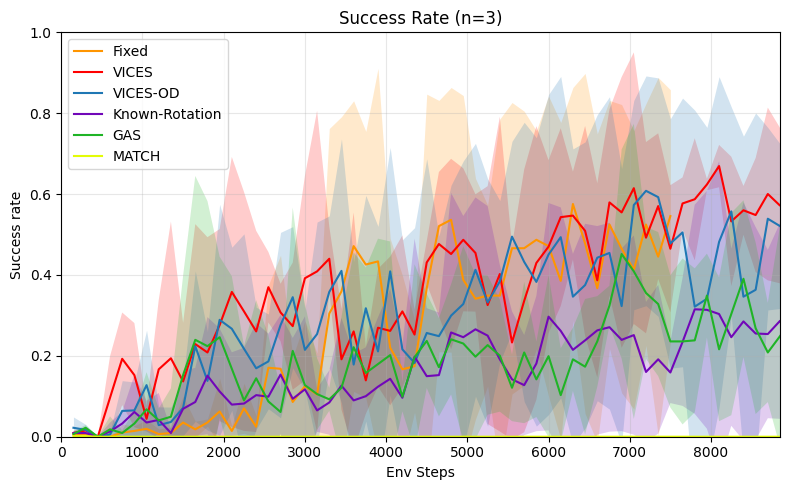

In [6]:
metric = "Episode / Success rate"
ylabel = "Success rate"
title = "Success Rate (Best)"
legend_loc = "upper left"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = (0, 1)              # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()

## 6b. Success rate (smoothed)

Same success-rate metric, run through a configurable sliding-window moving
average (`SMOOTH_WINDOW`) so the curves are easier to read.

saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/Episode_Success rate (smoothed).svg


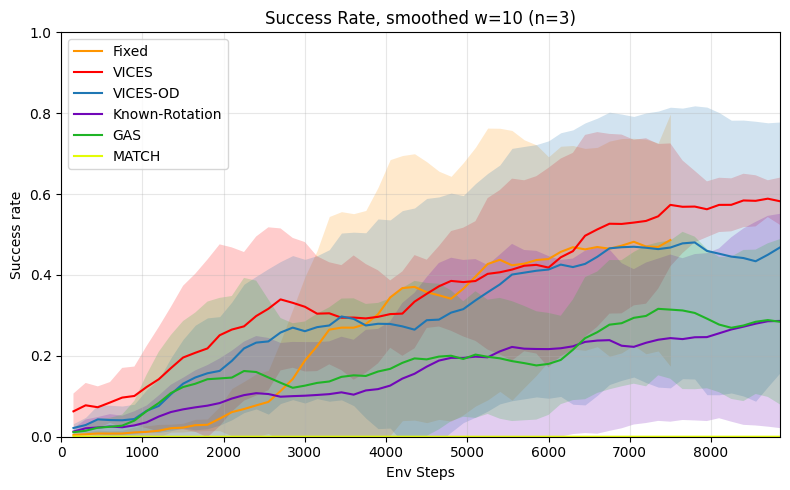

In [7]:
# Same success-rate data, but each run's curve is passed through a centered
# sliding-window moving average first so the lines are readable (less jitter).
# SMOOTH_WINDOW is the window length in data points; set it to 1 to disable.
SMOOTH_WINDOW = 10


def _moving_average(vals, window):
    """Centered moving average over `window` points.

    Edges shrink the window to the points available (no zero-padding dip), so
    the smoothed curve starts/ends on the real data rather than decaying to 0.
    """
    if window is None or window <= 1 or vals.size == 0:
        return vals
    w = int(min(window, vals.size))
    kernel = np.ones(w)
    sums = np.convolve(vals, kernel, mode="same")
    counts = np.convolve(np.ones_like(vals), kernel, mode="same")
    return sums / counts


def smooth_data(data, metric, window):
    """Copy of `data` with `metric`'s values replaced by their moving average.

    Steps are untouched; only the values are smoothed, and only for `metric`
    (every other tag is shared by reference). Runs without `metric` pass
    through unchanged.
    """
    out = {}
    for group, runs in data.items():
        new_runs = []
        for run in runs:
            if metric in run:
                steps, vals = run[metric]
                run = {**run, metric: (steps, _moving_average(vals, window))}
            new_runs.append(run)
        out[group] = new_runs
    return out


metric = "Episode / Success rate"
ylabel = "Success rate"
# Window goes in the base name; plot_metric replaces the trailing "(...)" with
# the trajectory count "(n=x)".
title = f"Success Rate, smoothed w={SMOOTH_WINDOW} (Best)"
legend_loc = "upper left"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = (0, 1)              # (min, max) or None to autoscale; None per-bound ok

smoothed = smooth_data(DATA, metric, SMOOTH_WINDOW)
ax = plot_metric(smoothed, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
# Distinct filename so it doesn't overwrite the un-smoothed success plot.
save_plot(ax.figure, metric + " (smoothed)")
plt.show()

## 7. Total reward

saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/Reward_Total reward (mean).svg


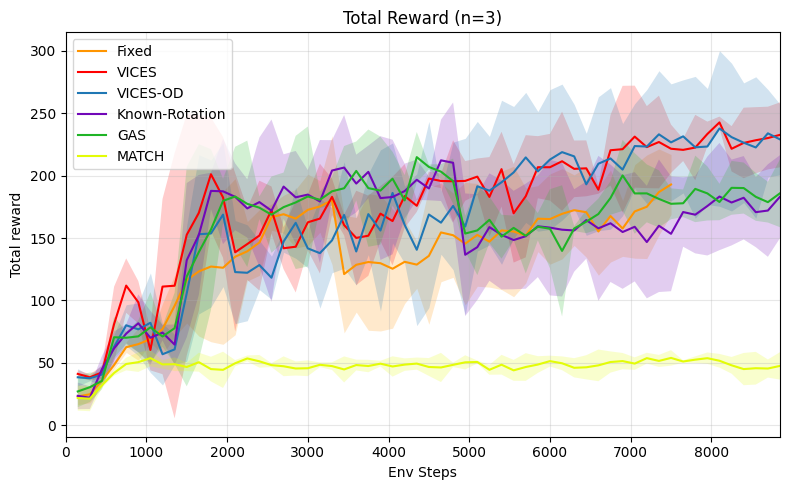

In [8]:
metric = "Reward / Total reward (mean)"
ylabel = "Total reward"
title = "Total Reward (n=3)"
legend_loc = "best"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = None                 # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()

## 8. Contact penalty

saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/logs_rew_contact_penalty.svg


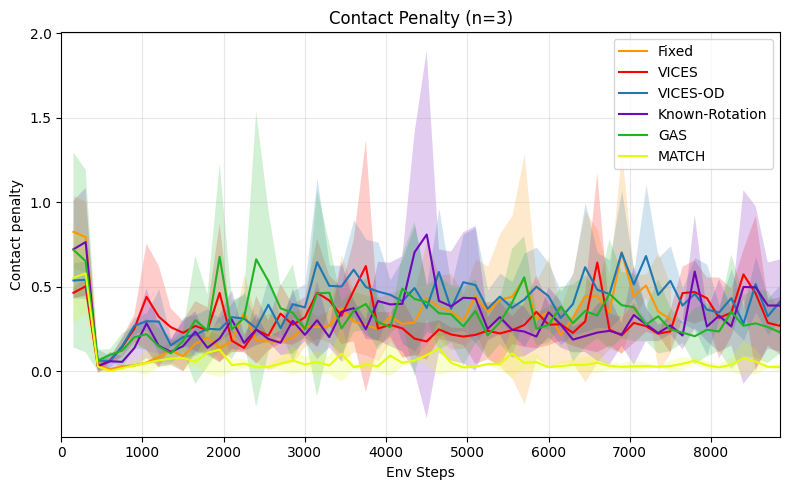

In [9]:
metric = "logs_rew/contact_penalty"
ylabel = "Contact penalty"
title = "Contact Penalty (n=3)"
legend_loc = "best"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = None                 # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()

## 9. Success times

[skip] metric 'success_times' not found in: 5_MATCH
saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/success_times.svg


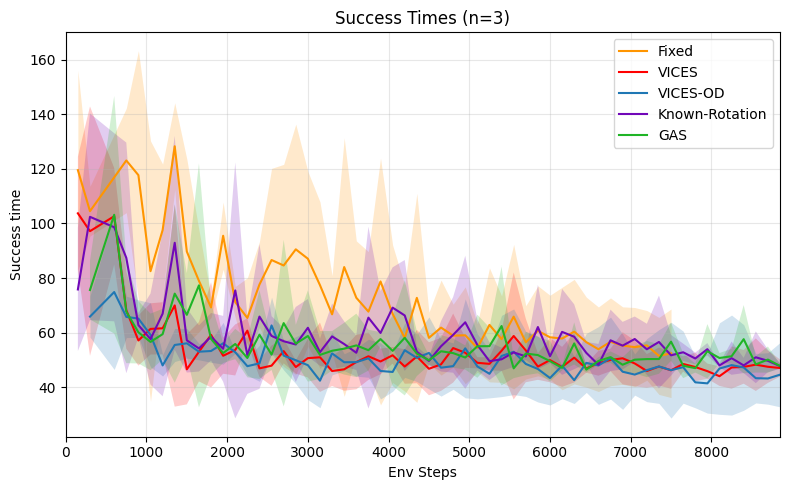

In [10]:
metric = "success_times"
ylabel = "Success time"
title = "Success Times (n=3)"
legend_loc = "best"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = None                 # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()

## 10. In-contact Z

saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/Contact_In-Contact Z.svg


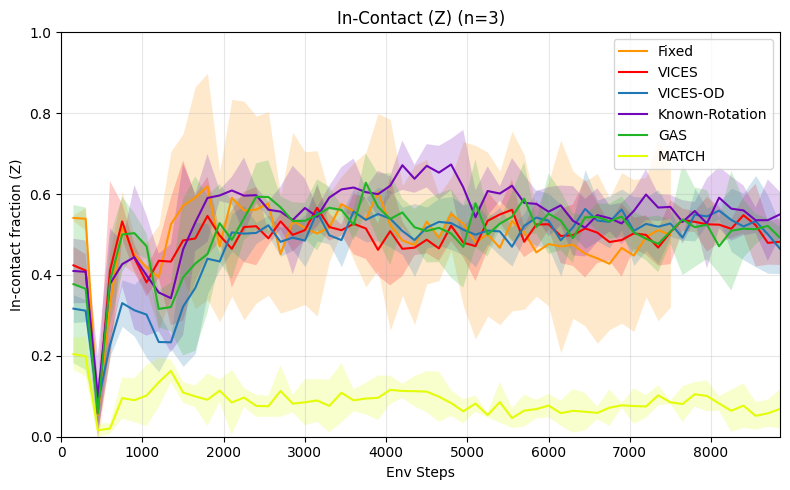

In [11]:
metric = "Contact / In-Contact Z"
ylabel = "In-contact fraction (Z)"
title = "In-Contact (Z) (n=3)"
legend_loc = "best"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = (0, 1)                 # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()

## 11. In-contact any

saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/Contact_In-Contact Any.svg


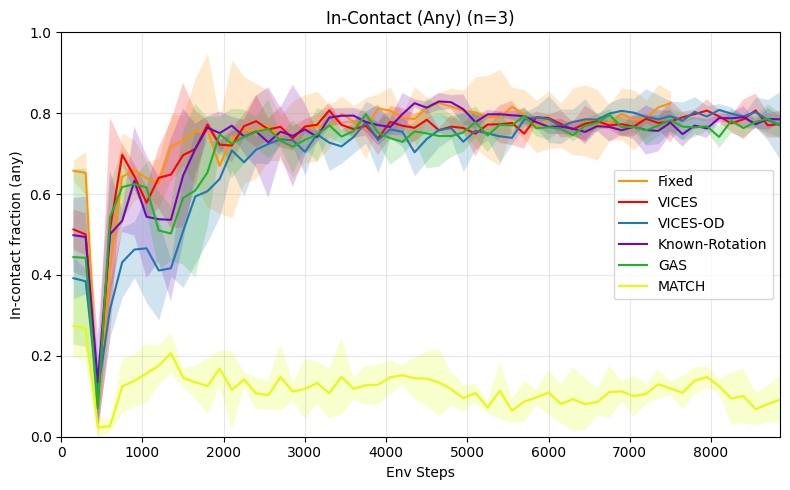

In [12]:
metric = "Contact / In-Contact Any"
ylabel = "In-contact fraction (any)"
title = "In-Contact (Any) (n=3)"
legend_loc = "best"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = (0, 1)                 # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()

## 12. Force control Z

[skip] metric 'Control Mode / Force Control Z' not found in: 1_fixed
[skip] metric 'Control Mode / Force Control Z' not found in: 2_VICES
[skip] metric 'Control Mode / Force Control Z' not found in: 3_VICES_OD
[skip] metric 'Control Mode / Force Control Z' not found in: 4-1_rotated_fixed
[skip] metric 'Control Mode / Force Control Z' not found in: 4_rotated_raw
saved /home/hunter/generalized_hybrid_vic_action_space/runs/long_dir/plots_20260614/Control Mode_Force Control Z.svg


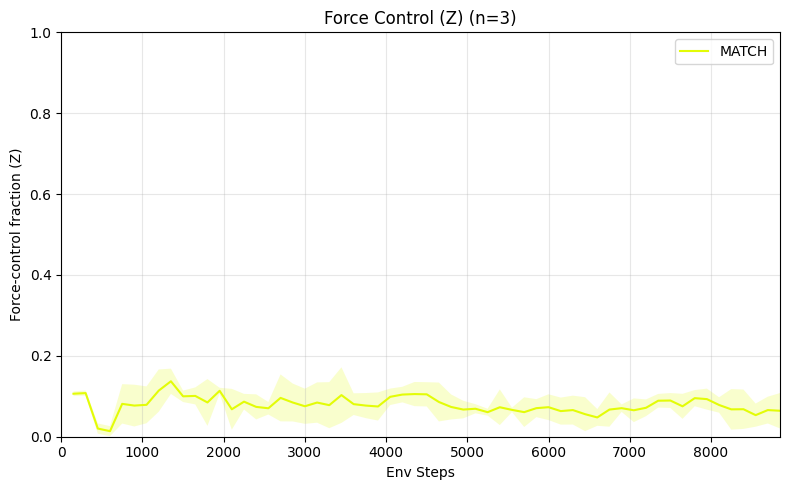

In [13]:
metric = "Control Mode / Force Control Z"
ylabel = "Force-control fraction (Z)"
title = "Force Control (Z) (n=3)"
legend_loc = "best"  # e.g. "best", "upper left", "lower right", or (x, y)
ylim = (0, 1)                 # (min, max) or None to autoscale; None per-bound ok

ax = plot_metric(DATA, metric, ylabel, title,
                 legend_loc=legend_loc, ylim=ylim)
ax.figure.tight_layout()
save_plot(ax.figure, metric)
plt.show()